<a href="https://colab.research.google.com/github/Carlitos-A/Optimizacion_analisis_red_neuronal/blob/main/Evaluacion1_MLP_Clasificacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EP1 Clasificación de Material Curricular con una Red Neuronal MLP

**Asignatura:** Deep Learning
**Evaluación:** EP1 – Implementación de una red neuronal MLP con TensorFlow/Keras
**Estudiantes:** *Carlos Camero y Carlos Muñoz*

---

## 1. Introducción

### 1.1 Descripción del problema

Se dispone de un dataset de **100.000 guías/documentos curriculares de matemáticas**, descritos por **22 características de contenido** (nivel escolar, duración estimada, número de páginas e ítems, proporciones de contenido por eje temático, densidad de símbolos, dificultad estimada, etc.). Cada documento pertenece a **una de 4 categorías curriculares** (clases 0, 1, 2 y 3), codificadas en la columna `categoria_curricular`.

### 1.2 Objetivo del modelo

Construir y evaluar una **red neuronal multicapa (MLP, Multi-Layer Perceptron)** implementada con **TensorFlow/Keras** que aprenda a clasificar automáticamente un documento curricular en su categoría correspondiente a partir de sus 22 características.

### 1.3 Tipo de clasificación

- **Clasificación supervisada multiclase (single-label):** cada ejemplo pertenece a exactamente una de las 4 clases.
- Las etiquetas son **enteras (0, 1, 2, 3)**, lo que influirá en la elección de la función de pérdida (se justificará en la Sección 5).
- La distribución de clases es: clase 0 = 30.219, clase 1 = 26.967, clase 2 = 23.065 y clase 3 = 19.749 ejemplos, es decir, un **desbalance Leve/Medio** que se tendrá en cuenta al interpretar las métricas.

### 1.4 Estructura de este notebook

1. Carga y exploración de datos. (Entre otros)
2. Preprocesamiento (separación X/y, split train/validación/test, escalado).
3. Construcción y entrenamiento del modelo MLP base.
4. Evaluación inicial del modelo base.
5. Próximos pasos (experimentos planificados).

**Nota metodológica:** siguiendo la rúbrica de la evaluación, **cada bloque de código está precedido por una celda Markdown que explica QUÉ se hace y POR QUÉ se hace**, de modo que todas las decisiones de diseño queden documentadas.

In [1]:
#--Librerías--
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
#----------------------------------
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report)

#Fijación de semillas
SEED = 42
random.seed(SEED)          # semilla del módulo random de Python
np.random.seed(SEED)       # semilla de NumPy
tf.random.set_seed(SEED)   # semilla de TensorFlow (inicialización de pesos, etc.)

print("Versión de TensorFlow:", tf.__version__)



Versión de TensorFlow: 2.20.0


##Carga y exploración de datos

###Importación de librerías y fijación de semillas

**¿Qué se hace?** Se importan todas las librerías necesarias y se fijan las semillas aleatorias de `random`, `numpy` y `tensorflow`.

**¿Por qué?**

- **pandas / numpy:** manipulación del dataset y operaciones numéricas.
- **matplotlib / seaborn:** visualizaciones (distribución de clases, curvas de entrenamiento, matriz de confusión).
- **tensorflow (Keras):** construcción y entrenamiento de la red neuronal MLP. (Se instancia la versión para confirmar que existe instaldo en Colab)
- **sklearn:** utilidades de preprocesamiento (`train_test_split`, `StandardScaler`) y métricas de evaluación.
- **Semillas:** las redes neuronales involucran procesos aleatorios (inicialización de pesos, orden de los batches). Fijar las semillas hace que los resultados sean **deterministas**, condición necesaria para que los experimentos posteriores sean comparables entre sí considerando esta semilla.

In [2]:
# Carga del dataset


NOMBRE_ARCHIVO = '/content/sample_data/Dataset_Clasificacion_Curricular_100000_LIMPIO.csv'

df = pd.read_csv(NOMBRE_ARCHIVO)
print(f"Dataset cargado correctamente: {df.shape[0]:,} filas x {df.shape[1]} columnas")

Dataset cargado correctamente: 100,000 filas x 23 columnas


##Carga del dataset

**¿Qué se hace?** Se carga el archivo CSV en un DataFrame de pandas usando una ruta relativa simple

In [5]:
# Inspección inicial: dimensiones, tipos, nulos y duplicados

print("Dimensiones del dataset (filas, columnas):", df.shape)

print("\n --------------------- Primeras 5 filas: ---------------------\n")
display(df.head())

print("\n------------------ Información de columnas y tipos de datos: ---------------------\n")
df.info()

print("\n------------------------- Valores nulos por columna: ----------------------------\n")
print(df.isnull().sum())

print("\n-------------------------- Número de filas duplicadas: ---------------------------\n", df.duplicated().sum())

Dimensiones del dataset (filas, columnas): (100000, 23)

 --------------------- Primeras 5 filas: ---------------------



,nivel_escolar,duracion_estimada_min,numero_paginas,numero_items,porcentaje_visual,densidad_simbolos,prop_operaciones_aritmeticas,prop_fracciones_decimales,prop_variables_algebraicas,prop_ecuaciones,...,prop_coordenadas,prop_tablas_graficos,prop_estadistica_descriptiva,prop_probabilidad,prop_contexto_problemas,dificultad_estimada,ejemplos_resueltos,elementos_visuales,indice_interactividad,categoria_curricular
0,7,41,18,25,54.42,0.2335,0.4200,0.6755,0.0752,0.1390,...,0.1448,0.5649,0.6283,0.2008,0.4641,2,0,5,0.3486,0
1,6,62,19,28,31.81,0.5357,0.5404,0.5512,0.4638,0.6847,...,0.3178,0.2299,0.2365,0.1484,0.7197,3,4,5,0.3725,1
2,12,49,12,27,46.90,0.3354,0.1622,0.3779,0.2806,0.4657,...,0.3686,0.0967,0.1067,0.0050,0.3689,3,2,6,0.2390,2
3,9,47,19,28,60.19,0.3546,0.1766,0.5883,0.1324,0.3927,...,0.1421,0.3458,0.4779,0.3623,0.4923,3,4,6,0.2807,3
4,8,32,14,12,72.43,0.2983,0.2337,0.0566,0.1475,0.3370,...,0.8311,0.4640,0.3562,0.2224,0.2690,2,3,6,0.0577,2



------------------ Información de columnas y tipos de datos: ---------------------

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 23 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   nivel_escolar                 100000 non-null  int64  
 1   duracion_estimada_min         100000 non-null  int64  
 2   numero_paginas                100000 non-null  int64  
 3   numero_items                  100000 non-null  int64  
 4   porcentaje_visual             100000 non-null  float64
 5   densidad_simbolos             100000 non-null  float64
 6   prop_operaciones_aritmeticas  100000 non-null  float64
 7   prop_fracciones_decimales     100000 non-null  float64
 8   prop_variables_algebraicas    100000 non-null  float64
 9   prop_ecuaciones               100000 non-null  float64
 10  prop_patrones_funciones       100000 non-null  float64
 11  prop_figuras_geometr

##Inspección inicial del dataset

**¿Qué se hace?** Se revisan las dimensiones del dataset (`shape`), las primeras filas (`head`), los tipos de datos (`info`), la cantidad de **valores nulos** y de **filas duplicadas**.

**¿Por qué?** Antes de entrenar cualquier modelo es obligatorio verificar la **calidad e integridad de los datos**: valores nulos o duplicados pueden sesgar el entrenamiento o inflar artificialmente las métricas. Confirmar los tipos de datos asegura que todas las columnas sean numéricas y aptas para alimentar una red neuronal.

Distribución de clases del target (categoria_curricular): 

-------------------------------------------------------------
categoria_curricular
0    30219
1    26967
2    23065
3    19749
Name: count, dtype: int64

Proporción por clase (%): 

-------------------------------------------------------------
categoria_curricular
0    30.22
1    26.97
2    23.06
3    19.75
Name: count, dtype: float64
-------------------------------------------------------------


/tmp/ipykernel_1133/3300685372.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='categoria_curricular', palette='viridis')


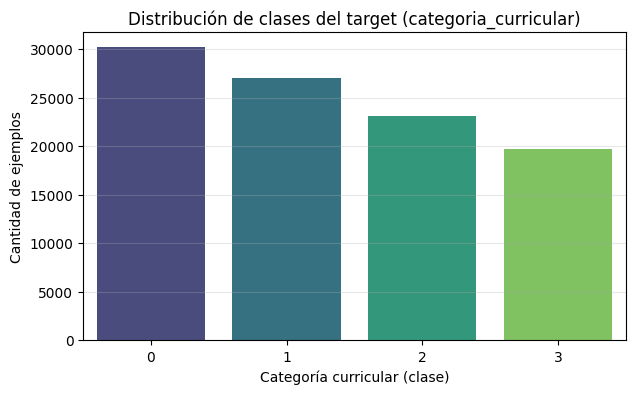

In [6]:
# Distribución de clases del target
conteo_clases = df['categoria_curricular'].value_counts().sort_index()

print("Distribución de clases del target (categoria_curricular): \n")
print("-------------------------------------------------------------")
print(conteo_clases)
print("\nProporción por clase (%): \n")
print("-------------------------------------------------------------")
print((conteo_clases / len(df) * 100).round(2))
print("-------------------------------------------------------------")

plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='categoria_curricular', palette='viridis')
plt.title('Distribución de clases del target (categoria_curricular)')
plt.xlabel('Categoría curricular (clase)')
plt.ylabel('Cantidad de ejemplos')
plt.grid(axis='y', alpha=0.3)
plt.show()

##Análisis de los hallazgos exploratorios

A partir de la exploración anterior (y del análisis exploratorio previo del dataset) se concluye:

- **Tamaño:** 100.000 filas × 23 columnas (22 features + 1 target). Es un volumen de datos suficiente para entrenar un MLP sin necesidad de técnicas de aumentación.

- **Calidad:** **no hay valores nulos ni filas duplicadas**, por lo que no se requiere imputación ni limpieza adicional.

- **Target:** clasificación multiclase con 4 clases y **desbalance leve** (clase mayoritaria ≈ 30,2% y minoritaria ≈ 19,7% del total). Al ser leve, **no se aplicarán técnicas de rebalanceo**, pero se evaluará con métricas por clase (precision, recall, F1) además del accuracy.

- **Escalas heterogéneas:** algunas features están en rango 0–1 (las 12 columnas `prop_*`, `densidad_simbolos`, `indice_interactividad`), mientras otras llegan hasta 95 (`porcentaje_visual`), 83 (`duracion_estimada_min`) o 43 (`numero_items`). Esto **justifica el escalado** de las variables.

- **Correlaciones con el target:** las más altas son `prop_operaciones_aritmeticas` (−0,53), `prop_fracciones_decimales` (−0,50), `prop_tablas_graficos` (+0,46), `prop_probabilidad` (+0,44) y `prop_estadistica_descriptiva` (+0,44). Esto sugiere que la composición temática del documento es muy informativa para la clasificación.

- **Multicolinealidad:** no existen pares de features con correlación superior a 0,8, por lo que **no es necesario eliminar variables redundantes**; las 22 features se conservan como entrada del modelo.

Es un muy buen dataset para empezar el entrenamiento.

In [7]:
# Separación de features (X) y target (y)

TARGET = 'categoria_curricular'

X = df.drop(columns=[TARGET])  # 22 features de entrada
y = df[TARGET]                 # etiquetas enteras 0-3

print("---Features (X):---\n", X.shape)
print("---Target   (y):---\n", y.shape)
print("\n---Columnas utilizadas como features:--- \n")
print(list(X.columns))

---Features (X):---
 (100000, 22)
---Target   (y):---
 (100000,)

---Columnas utilizadas como features:--- 

['nivel_escolar', 'duracion_estimada_min', 'numero_paginas', 'numero_items', 'porcentaje_visual', 'densidad_simbolos', 'prop_operaciones_aritmeticas', 'prop_fracciones_decimales', 'prop_variables_algebraicas', 'prop_ecuaciones', 'prop_patrones_funciones', 'prop_figuras_geometricas', 'prop_medicion_angulos', 'prop_coordenadas', 'prop_tablas_graficos', 'prop_estadistica_descriptiva', 'prop_probabilidad', 'prop_contexto_problemas', 'dificultad_estimada', 'ejemplos_resueltos', 'elementos_visuales', 'indice_interactividad']


## Preprocesamiento
###Separación de features (X) y target (y)

**¿Qué se hace?** Se separa la columna target `categoria_curricular` (vector `y`) del resto de las columnas (matriz de features `X`).

**¿Por qué?** Los algoritmos de aprendizaje supervisado requieren por separado las **variables de entrada** y la **variable a predecir**. Además, separarlas explícitamente evita errores típicos como incluir accidentalmente el target como feature (lo que produciría una fuga de información y métricas artificialmente perfectas).

In [8]:
# Separación del 15% final como conjunto de prueba (test)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.15,
    stratify=y,
    random_state=42
)

# Dividir el 85% restante en train (70%) y validación (15%)
# 0.15/0.85 ≈ 0.1765 del conjunto temporal equivale al 15% del total
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.15 / 0.85,
    stratify=y_temp,
    random_state=42
)

# Verificación de tamaños y proporciones
for nombre, conjunto in [('-Train', y_train), ('-Validación', y_val), ('-Test', y_test)]:
    print(f"{nombre}: {len(conjunto):,} \n -Ejemplos ({len(conjunto) / len(y) * 100:.1f}%)")

print("\n---Proporción de clases por conjunto (debe ser similar, gracias a stratify):---")
resultados = {}
for nombre, conjunto in [
    ('-Train', y_train),
    ('-Validación', y_val),
    ('-Test', y_test)]:
    props = (
        conjunto.value_counts(normalize=True)
        .sort_index() * 100
    ).round(2)

    resultados[nombre] = props

tabla = pd.DataFrame(resultados).T

print("Proporción de clases por conjunto (%):")
display(tabla)

-Train: 69,999 
 -Ejemplos (70.0%)
-Validación: 15,001 
 -Ejemplos (15.0%)
-Test: 15,000 
 -Ejemplos (15.0%)

---Proporción de clases por conjunto (debe ser similar, gracias a stratify):---
Proporción de clases por conjunto (%):


categoria_curricular,0,1,2,3
-Train,30.22,26.97,23.06,19.75
-Validación,30.22,26.96,23.07,19.75
-Test,30.22,26.97,23.07,19.75


##División train / validación / test (70 / 15 / 15)

**¿Qué se hace?** Se divide el dataset en tres conjuntos: **70% entrenamiento, 15% validación y 15% prueba**, en dos pasos:

1. Primero se separa el **15% final como test** (queda un 85% temporal).
2. Luego ese 85% se divide en **train (70% del total)** y **validación (15% del total)**, usando `test_size = 0.15/0.85 ≈ 0.1765` sobre el conjunto temporal.

Ambos pasos usan `stratify=y` y `random_state=42`.

**¿Por qué?**

- **Tres conjuntos y no dos:** el conjunto de **validación** se usa para monitorear el entrenamiento y ajustar hiperparámetros, mientras que el de **prueba (test)** se reserva para la **evaluación final**, sin haber sido visto en ninguna decisión. Así la evaluación es una estimación honesta del desempeño en datos nuevos.
- **`stratify=y`:** garantiza que la proporción de las 4 clases se mantenga en los tres conjuntos, importante dado el desbalance leve del target.
- **`random_state=42`:** hace la división **reproducible**; cualquier ejecución del notebook genera exactamente los mismos conjuntos.

In [9]:
# Escalado: StandardScaler ajustado SOLO con train. Esto para lograr que las columnas con escalas diferentes sean más estandar.
scaler = StandardScaler()

# IMPORTANTE: el scaler se ajusta (fit) SOLO con el conjunto de entrenamiento
X_train_scaled = scaler.fit_transform(X_train)

# El StandardScaler aprende cómo son los datos usando solamente X_train y después transforma X_train usando lo que aprendió.

# Validación y test solo se TRANSFORMAN con los parámetros aprendidos de train
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


print("Escalado completado. Media y desviación estándar aprendidas de train:")
print("  Media (primeras 5 features):", np.round(scaler.mean_[:5], 3))
print("  Escala (primeras 5 features):", np.round(scaler.scale_[:5], 3))

Escalado completado. Media y desviación estándar aprendidas de train:
  Media (primeras 5 features): [ 8.493 37.08  13.205 19.664 53.62 ]
  Escala (primeras 5 features): [ 2.293 10.923  4.914  5.954 15.45 ]


###Escalado de features con StandardScaler

**¿Qué se hace?** Se estandarizan las 22 features con `StandardScaler` (media 0, desviación estándar 1). El scaler se **ajusta (`fit`) SOLO con el conjunto de entrenamiento** y luego se **aplica (`transform`)** a validación y test.

**¿Por qué?**

- **Escalas heterogéneas:** como se vio en la exploración, hay features en rango 0–1 junto a otras que llegan a 95. Las redes neuronales entrenan por descenso de gradiente, y cuando las variables tienen escalas muy distintas la optimización se vuelve lenta e inestable (los gradientes quedan dominados por las variables de mayor magnitud). Estandarizar pone todas las features en pie de igualdad y **acelera y estabiliza la convergencia**.
- **Ajustar solo con train (evitar data leakage):** si el scaler se ajustara con todo el dataset, la media y desviación de los conjuntos de validación y test "filtrarían" información hacia el entrenamiento. Eso es **fuga de datos (data leakage)** y produce métricas optimistas que no se sostienen en producción. Por eso: `fit` solo en train, `transform` en los tres.

In [10]:
# Verificación de shapes y del efecto del escalado
print("Shapes finales:")
print(f"  X_train: {X_train_scaled.shape} | y_train: {y_train.shape}")
print(f"  X_val:   {X_val_scaled.shape} | y_val:   {y_val.shape}")
print(f"  X_test:  {X_test_scaled.shape} | y_test:  {y_test.shape}")

print("\nMedia por feature en train escalado (debe ser ≈ 0):")
print(np.round(X_train_scaled.mean(axis=0), 2))

print("\nDesviación estándar por feature en train escalado (debe ser ≈ 1):")
print(np.round(X_train_scaled.std(axis=0), 2))

Shapes finales:
  X_train: (69999, 22) | y_train: (69999,)
  X_val:   (15001, 22) | y_val:   (15001,)
  X_test:  (15000, 22) | y_test:  (15000,)

Media por feature en train escalado (debe ser ≈ 0):
[-0.  0. -0.  0. -0. -0.  0.  0.  0.  0. -0. -0.  0. -0. -0. -0. -0. -0.
 -0.  0.  0.  0.]

Desviación estándar por feature en train escalado (debe ser ≈ 1):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


###Verificación de las dimensiones finales

**¿Qué se hace?** Se imprimen las dimensiones (`shape`) de todos los conjuntos y se comprueba que, tras el escalado, las features de train tengan media ≈ 0, todos iguales en un estandar de escala clave y desviación estándar ≈ 1. Esto cumple como una especie de control de calidad después del escalado con StandardScale

**¿Por qué?** Verificar las dimensiones antes de modelar permite detectar de inmediato errores en el split o en el escalado (por ejemplo, pérdida de columnas o de filas), y confirmar que la estandarización se aplicó correctamente. La dimensión de entrada de `X_train` (22) definirá la capa de entrada de la red.

In [11]:
# Definición de la arquitectura del MLP base
def crear_modelo_base(n_features, n_clases):
    """Construye el MLP base: Input(22) -> Dense(64, relu) -> Dense(32, relu) -> Dense(4, softmax)."""
    modelo = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(n_features,)),               # 22 features de entrada
        tf.keras.layers.Dense(64, activation='relu', name='capa_oculta_1'),
        tf.keras.layers.Dense(32, activation='relu', name='capa_oculta_2'),
        tf.keras.layers.Dense(n_clases, activation='softmax', name='capa_salida')
    ], name='MLP_base')
    return modelo

n_features = X_train_scaled.shape[1]  # 22 features
n_clases = y_train.nunique()          # 4 clases

modelo_base = crear_modelo_base(n_features, n_clases)

##Modelo MLP base con Keras

###Arquitectura de la red

**¿Qué se hace?** Se define una red neuronal **secuencial** con la siguiente arquitectura:

| Capa | Neuronas | Activación |
|------|------|----------|
| Entrada | 22 | — | Una neurona por feature |
| Oculta 1 | 64 | ReLU | Extracción de patrones de alto nivel |
| Oculta 2 | 32 | ReLU | Refinamiento de la representación |
| Salida | 4 | Softmax | Una neurona por clase |

**¿Por qué esta arquitectura?**

- **MLP (capas densas):** las features son **tabulares** (no imágenes ni secuencias), por lo que un perceptrón multicapa totalmente conectado es el modelo apropiado; no se justifican capas convolucionales ni recurrentes.
- **Dos capas ocultas (64 → 32):** es una arquitectura **base razonable y parsimoniosa** para 22 features y 100.000 ejemplos: suficiente capacidad para aprender relaciones no lineales, pero pequeña para entrenar rápido y servir de **línea base** contra la cual comparar los experimentos posteriores. La reducción progresiva (64 → 32 → 4) obliga a la red a comprimir la información en representaciones cada vez más abstractas.
- **ReLU en las capas ocultas:** es la activación estándar en redes profundas por su buen comportamiento y su bajo costo computacional.
- **4 neuronas de salida:** una por cada categoría curricular.

In [12]:
# Compilación del modelo base
modelo_base.compile(
    optimizer=tf.keras.optimizers.Adam(),   # learning_rate por defecto = 0.001
    loss='sparse_categorical_crossentropy', # etiquetas enteras 0-3 (sin one-hot)
    metrics=['accuracy']
)

modelo_base.summary()

Model: "MLP_base"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ capa_oculta_1 (Dense)           │ (None, 64)             │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_oculta_2 (Dense)           │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_salida (Dense)             │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,684 (14.39 KB)

 Trainable params: 3,684 (14.39 KB)

 Non-trainable params: 0 (0.00 B)

###Compilación del modelo

**¿Qué se hace?** Se compila el modelo con optimizador **Adam** (learning rate por defecto = 0,001), función de pérdida **`sparse_categorical_crossentropy`** y métrica **`accuracy`**.

**¿Por qué?**

- **Softmax en la capa de salida:** convierte los 4 valores de salida (logits) en una **distribución de probabilidad** sobre las clases (valores entre 0 y 1 que suman 1). Es la activación estándar para clasificación **multiclase single-label**, porque modela exactamente la pregunta "¿a cuál de las 4 categorías pertenece este documento?".
- **`sparse_categorical_crossentropy`:** es la entropía cruzada categórica para el caso en que las etiquetas son **enteros (0, 1, 2, 3)** en lugar de vectores one-hot. Es la pérdida correcta para multiclase porque mide la discrepancia entre la distribución predicha por softmax y la clase real; la variante *sparse* evita tener que convertir `y` a one-hot, ahorrando memoria y código. (La alternativa `categorical_crossentropy` requeriría `to_categorical(y)`.)
- **Adam:** optimizador adaptativo que ajusta la tasa de aprendizaje de cada parámetro combinando momentum y RMSProp. Converge rápido y de forma robusta con sus valores por defecto, por lo que es la elección estándar como **punto de partida**; en la Sección 6 se experimentará con otras tasas de aprendizaje.
- **Métrica `accuracy`:** proporción de aciertos; es intuitiva y sirve para monitorear el entrenamiento, aunque la evaluación final (Sección 5) la complementará con precision, recall y F1.

In [14]:
# Entrenamiento del modelo base

EPOCHS = 50
BATCH_SIZE = 32

historia_base = modelo_base.fit(
    X_train_scaled, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_scaled, y_val),
    verbose=1
)

Epoch 1/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9138 - loss: 0.2320 - val_accuracy: 0.9137 - val_loss: 0.2358
Epoch 2/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9141 - loss: 0.2310 - val_accuracy: 0.9136 - val_loss: 0.2362
Epoch 3/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9144 - loss: 0.2299 - val_accuracy: 0.9129 - val_loss: 0.2365
Epoch 4/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9147 - loss: 0.2290 - val_accuracy: 0.9129 - val_loss: 0.2371
Epoch 5/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9150 - loss: 0.2281 - val_accuracy: 0.9131 - val_loss: 0.2373
Epoch 6/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9151 - loss: 0.2272 - val_accuracy: 0.9130 - val_loss: 0.2378
Epoch 7/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9155 - loss: 0.2264 - val_accuracy: 0.9127 - val_loss: 0.2382
Epoch 8/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9160 - loss: 0.2256 - 

###Entrenamiento del modelo base

**¿Qué se hace?** Se entrena el modelo durante **50 épocas** con **batch_size = 32**, usando el conjunto de validación como `validation_data`.

**¿Por qué?**

- **`epochs = 50`:** un número moderado que permite observar la evolución completa del aprendizaje (y detectar visualmente sobreajuste en las curvas) sin que el tiempo de cómputo sea excesivo. Es la configuración **inicial** que luego se variará experimentalmente.
- **`batch_size = 32`:** valor estándar que equilibra estabilidad del gradiente (batches no demasiado pequeños) y frecuencia de actualización de los pesos (batches no demasiado grandes).
- **`validation_data = (X_val_scaled, y_val)`:** en cada época Keras evalúa la pérdida y el accuracy sobre el conjunto de validación **sin usarlo para actualizar pesos**. Esto permite monitorear la **capacidad de generalización** durante el entrenamiento y detectar sobreajuste.
- El historial devuelto por `fit()` se guarda en `historia_base` para graficar las curvas en la siguiente celda.

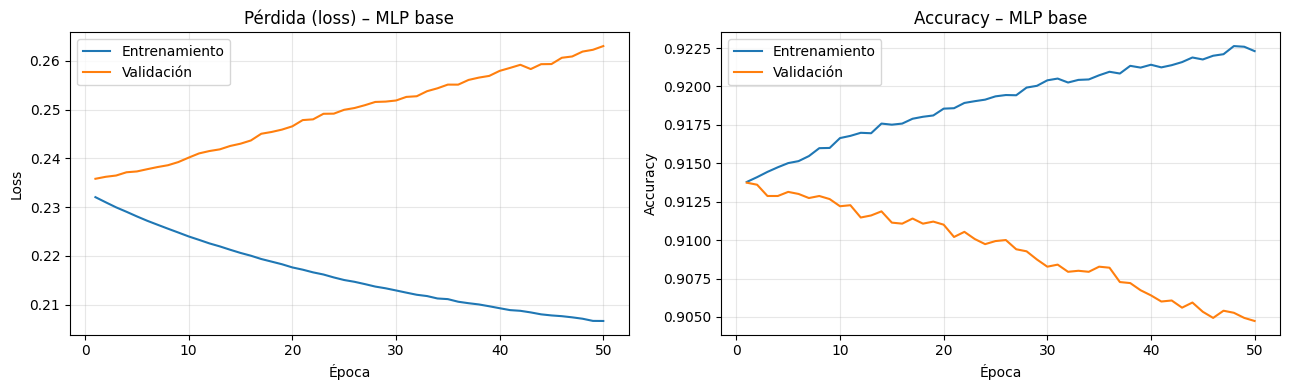

In [15]:
# Gráfico de curvas de pérdida y accuracy (train vs validación)
def graficar_curvas(historia, titulo='Modelo base'):
    """Grafica las curvas de pérdida y accuracy de entrenamiento y validación."""
    hist = historia.history
    epocas = range(1, len(hist['loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Curva de pérdida
    axes[0].plot(epocas, hist['loss'], label='Entrenamiento')
    axes[0].plot(epocas, hist['val_loss'], label='Validación')
    axes[0].set_title(f'Pérdida (loss) – {titulo}')
    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Curva de accuracy
    axes[1].plot(epocas, hist['accuracy'], label='Entrenamiento')
    axes[1].plot(epocas, hist['val_accuracy'], label='Validación')
    axes[1].set_title(f'Accuracy – {titulo}')
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

graficar_curvas(historia_base, titulo='MLP base')

### Curvas de aprendizaje (loss y accuracy)

**¿Qué se hace?** Se grafican las curvas de **pérdida** y **accuracy** de entrenamiento y validación a lo largo de las épocas.

**¿Por qué?** Las curvas de aprendizaje son la principal herramienta de **diagnóstico** del entrenamiento:

- Si la pérdida de **entrenamiento** sigue bajando mientras la de **validación** se estanca o sube, hay **sobreajuste (overfitting)**.
- Si ambas quedan altas y planas, hay **subajuste (underfitting)**.
- La brecha entre las curvas de train y validación indica cuánto generaliza el modelo.

Este diagnóstico orienta los experimentos de la Sección 6 (regularización, número de épocas, etc.).

In [16]:
# Predicciones y métricas sobre el conjunto de prueba
# Probabilidades softmax -> etiqueta de mayor probabilidad (argmax)

y_pred_prob = modelo_base.predict(X_test_scaled)
y_pred = np.argmax(y_pred_prob, axis=1)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("=== Métricas del MLP base en el conjunto de PRUEBA ===")
print(f"Accuracy            : {accuracy:.4f}")
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall    (weighted): {recall:.4f}")
print(f"F1-score  (weighted): {f1:.4f}")

print("\nReporte de clasificación por clase:")
print(classification_report(y_test, y_pred))

469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
=== Métricas del MLP base en el conjunto de PRUEBA ===
Accuracy            : 0.9033
Precision (weighted): 0.9033
Recall    (weighted): 0.9033
F1-score  (weighted): 0.9033

Reporte de clasificación por clase:
              precision    recall  f1-score   support

           0       0.90      0.90      0.90      4533
           1       0.91      0.91      0.91      4045
           2       0.90      0.90      0.90      3460
           3       0.91      0.90      0.91      2962

    accuracy                           0.90     15000
   macro avg       0.90      0.90      0.90     15000
weighted avg       0.90      0.90      0.90     15000



## Evaluación inicial del modelo base

### Métricas de clasificación sobre el conjunto de prueba

**¿Qué se hace?** Se generan las predicciones sobre el **conjunto de prueba** (que el modelo nunca vio durante el entrenamiento ni el ajuste) y se calculan **accuracy, precision, recall y F1-score** con `average='weighted'`, más el reporte por clase.

**¿Por qué?**

- **No basta con el accuracy:** con 4 clases y desbalance leve, el accuracy global puede ocultar un mal desempeño en la clase minoritaria. Precision, recall y F1 permiten ver el comportamiento **por clase**.
- **`average='weighted'`:** calcula cada métrica por clase y las promedia **ponderando por el soporte** (número de ejemplos reales de cada clase). Se elige esta variante porque refleja el desempeño global esperado sobre la distribución real de los datos. *(La alternativa `average='macro'` pondera todas las clases por igual; dado que el desbalance es leve, ambas deberían dar valores cercanos, y su comparación queda como ejercicio de análisis.)*
- **De probabilidades a etiquetas:** `predict()` devuelve las probabilidades softmax de las 4 clases; `argmax` selecciona la clase de mayor probabilidad, que es la decisión de clasificación natural en un problema single-label.


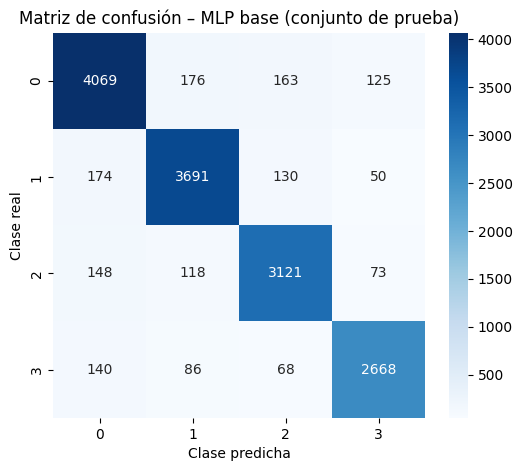

In [17]:
# Matriz de confusión (heatmap)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0, 1, 2, 3], yticklabels=[0, 1, 2, 3])
plt.title('Matriz de confusión – MLP base (conjunto de prueba)')
plt.xlabel('Clase predicha')
plt.ylabel('Clase real')
plt.show()

###Matriz de confusión

**¿Qué se hace?** Se calcula y visualiza la **matriz de confusión** de las predicciones sobre el conjunto de prueba, con un mapa de calor (`heatmap`).

**¿Por qué?** La matriz de confusión muestra **qué clases se confunden entre sí**: la diagonal principal contiene los aciertos y las celdas fuera de la diagonal, los errores. Esto permite identificar, por ejemplo, si las categorías curriculares adyacentes en dificultad o contenido se confunden más entre sí, información que ninguna métrica agregada entrega y que orienta mejoras posteriores (más capacidad, regularización, features adicionales, etc.).

In [18]:
# Cuadro resumen: línea base del modelo MLP base
resumen_base = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision (weighted)', 'Recall (weighted)', 'F1-score (weighted)'],
    'MLP base (test)': [round(accuracy, 4), round(precision, 4),
                        round(recall, 4), round(f1, 4)]
})

print("=== CUADRO RESUMEN – Evaluación inicial del MLP base ===")
print(resumen_base.to_string(index=False))

=== CUADRO RESUMEN – Evaluación inicial del MLP base ===
             Métrica  MLP base (test)
            Accuracy           0.9033
Precision (weighted)           0.9033
   Recall (weighted)           0.9033
 F1-score (weighted)           0.9033


###Cuadro resumen de la evaluación inicial

**¿Qué se hace?** Se consolidan las métricas del modelo base en un cuadro resumen que servirá como **línea base (baseline)** de referencia.

**¿Por qué?** Todos los experimentos de la Sección 6 (variación de hiperparámetros, regularización, etc.) se compararán contra estos valores para determinar de forma objetiva si cada cambio **mejora, empeora o no afecta** el desempeño del modelo.

## Conclusiones de la evaluación inicial

**Desempeño global:** El modelo base alcanzó un accuracy de 0,9033 en el conjunto de prueba, con precision, recall y F1-score weighted también en 0,9033, lo que indica un desempeño parejo entre las 4 clases sin un sesgo evidente hacia la clase mayoritaria pese al desbalance leve del dataset.

**Clases con más errores:** La clase 0 (Números y Operaciones) es la que concentra más confusiones con el resto, especialmente con la clase 1 (Álgebra y Funciones): 176 casos de clase 0 predichos como clase 1 y 174 casos de clase 1 predichos como clase 0, el par más confundido de la matriz. También hay confusión relevante entre clase 0 y clase 2 (Geometría) y entre clase 1 y clase 2. Esto es consistente con que Números/Operaciones y Álgebra comparten mucho contenido numérico y simbólico (operaciones, fracciones, ecuaciones), lo que dificulta al modelo distinguirlas solo a partir de las 22 features de proporción temática. La clase con mejor recall individual es la 1 (Álgebra, ≈91,3%), y la de mayor dificultad relativa es la 3 (Datos y Probabilidad), pese a tener el menor desbalance de soporte.

**Diagnóstico de las curvas de aprendizaje:** El modelo base mostró un ligero indicio de sobreajuste hacia el final del entrenamiento, con una pequeña brecha entre el loss de entrenamiento y validación, aunque mucho menos marcada que la observada luego con Tanh o MSE.

**Hipótesis para mejorar:** A partir de este diagnóstico, se plantearon como hipótesis reducir el learning rate y aplicar Dropout como técnica de regularización, ambas confirmadas como efectivas en los experimentos de la Sección 6.

## Experimento 1: Comparación de funciones de activación (ReLU vs Tanh)

**¿Qué se hace?** Se entrena un segundo modelo, idéntico en arquitectura al MLP base (22 → 64 → 32 → 4), pero reemplazando la activación ReLU por Tanh en las dos capas ocultas. Se mantienen fijos: arquitectura, función de pérdida, optimizador, batch size, épocas y learning rate.

**¿Por qué?** ReLU y Tanh se comportan distinto durante el entrenamiento: ReLU no satura para valores positivos y suele converger más rápido, mientras que Tanh satura en ±1 y puede generar gradientes más pequeños (vanishing gradient) en redes con más profundidad. Comparar ambas permite justificar con evidencia por qué se eligió ReLU como activación del modelo base.

Epoch 1/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9043 - loss: 0.2645 - val_accuracy: 0.9137 - val_loss: 0.2401
Epoch 2/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9101 - loss: 0.2442 - val_accuracy: 0.9135 - val_loss: 0.2395
Epoch 3/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9106 - loss: 0.2423 - val_accuracy: 0.9141 - val_loss: 0.2392
Epoch 4/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9111 - loss: 0.2408 - val_accuracy: 0.9137 - val_loss: 0.2391
Epoch 5/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9113 - loss: 0.2396 - val_accuracy: 0.9141 - val_loss: 0.2391
Epoch 6/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9117 - loss: 0.2385 - val_accuracy: 0.9139 - val_loss: 0.2393
Epoch 7/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9123 - loss: 0.2374 - val_accuracy: 0.9131 - val_loss: 0.2396
Epoch 8/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9125 - loss: 0.2364 - 

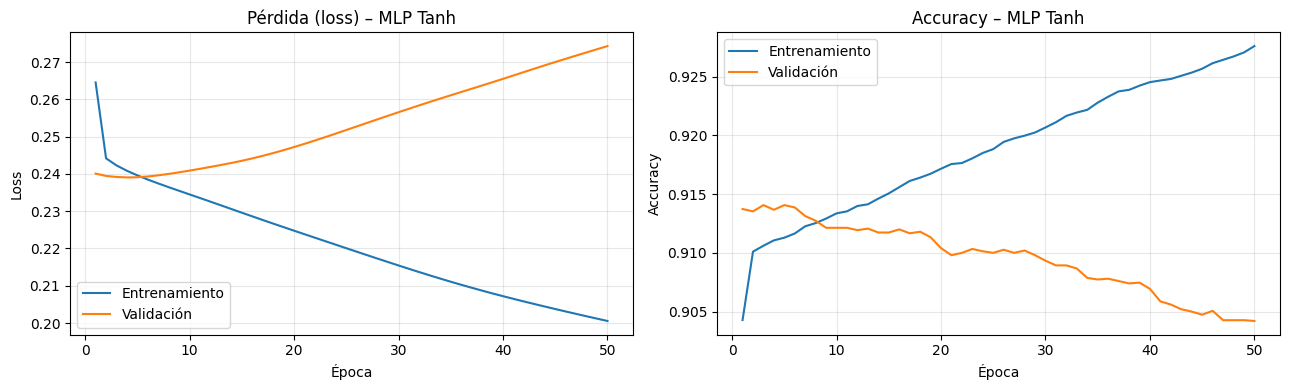

In [19]:
# Experimento 1: modelo con activación Tanh en las capas ocultas
def crear_modelo_tanh(n_features, n_clases):
    """MLP idéntico al base pero con Tanh en las capas ocultas."""
    modelo = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(n_features,)),
        tf.keras.layers.Dense(64, activation='tanh', name='capa_oculta_1'),
        tf.keras.layers.Dense(32, activation='tanh', name='capa_oculta_2'),
        tf.keras.layers.Dense(n_clases, activation='softmax', name='capa_salida')
    ], name='MLP_tanh')
    return modelo

modelo_tanh = crear_modelo_tanh(n_features, n_clases)

modelo_tanh.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

historia_tanh = modelo_tanh.fit(
    X_train_scaled, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_scaled, y_val),
    verbose=1
)

graficar_curvas(historia_tanh, titulo='MLP Tanh')

In [20]:
# Evaluación del modelo Tanh en test
y_pred_prob_tanh = modelo_tanh.predict(X_test_scaled)
y_pred_tanh = np.argmax(y_pred_prob_tanh, axis=1)

accuracy_tanh = accuracy_score(y_test, y_pred_tanh)
precision_tanh = precision_score(y_test, y_pred_tanh, average='weighted')
recall_tanh = recall_score(y_test, y_pred_tanh, average='weighted')
f1_tanh = f1_score(y_test, y_pred_tanh, average='weighted')

# Tabla comparativa ReLU (base) vs Tanh
comparacion_activacion = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision (weighted)', 'Recall (weighted)', 'F1-score (weighted)'],
    'ReLU (base)': [round(accuracy, 4), round(precision, 4), round(recall, 4), round(f1, 4)],
    'Tanh': [round(accuracy_tanh, 4), round(precision_tanh, 4), round(recall_tanh, 4), round(f1_tanh, 4)]
})

print("=== Comparación de funciones de activación: ReLU vs Tanh ===")
print(comparacion_activacion.to_string(index=False))

469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
=== Comparación de funciones de activación: ReLU vs Tanh ===
             Métrica  ReLU (base)   Tanh
            Accuracy       0.9033 0.9021
Precision (weighted)       0.9033 0.9021
   Recall (weighted)       0.9033 0.9021
 F1-score (weighted)       0.9033 0.9021


### Conclusión del Experimento 1: ReLU vs Tanh

**Resultado:** ReLU (modelo base) obtuvo mejor desempeño en las 4 métricas sobre el conjunto de prueba (Accuracy, Precision, Recall y F1-score: 0,9033 vs 0,9021 de Tanh). La diferencia numérica es pequeña, pero las curvas de aprendizaje muestran una razón más relevante para preferir ReLU: el modelo con Tanh presenta **overfitting visible** desde aproximadamente la época 10, donde el loss de validación empieza a subir mientras el de entrenamiento sigue bajando, y el accuracy de validación decae de ~0,915 a ~0,904. El modelo base con ReLU no mostró esta divergencia entre train y validación en el mismo rango de épocas.

**¿Por qué ocurre esto?** Tanh satura en ±1, lo que puede generar gradientes más pequeños y hacer que el modelo se ajuste de forma menos estable a medida que avanzan las épocas, favoreciendo la memorización del set de entrenamiento por sobre la generalización. Esto respalda la elección de ReLU como activación para las capas ocultas del modelo final.

## Experimento 2: Comparación de funciones de pérdida (Sparse Categorical Crossentropy vs MSE)

**¿Qué se hace?** Se entrena un tercer modelo, con la misma arquitectura del MLP base (22 → 64 ReLU → 32 ReLU → 4 Softmax), pero cambiando la función de pérdida de `sparse_categorical_crossentropy` a `mean_squared_error` (MSE). Como MSE no trabaja con etiquetas enteras, `y` se transforma temporalmente a formato one-hot solo para este experimento. Se mantienen fijos: arquitectura, optimizador, batch size, épocas y learning rate.

**¿Por qué?** Crossentropy está diseñada específicamente para clasificación: penaliza con fuerza cuando el modelo está muy seguro y se equivoca, y su gradiente es más informativo cuando se combina con Softmax. MSE está pensada para regresión y, aplicada a probabilidades softmax, generalmente produce gradientes más débiles y un aprendizaje más lento. Comparar ambas permite justificar con evidencia por qué se eligió Sparse Categorical Crossentropy como pérdida del modelo base.

Epoch 1/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8980 - loss: 0.0377 - val_accuracy: 0.9122 - val_loss: 0.0326
Epoch 2/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9107 - loss: 0.0331 - val_accuracy: 0.9129 - val_loss: 0.0324
Epoch 3/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9113 - loss: 0.0327 - val_accuracy: 0.9123 - val_loss: 0.0324
Epoch 4/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9125 - loss: 0.0325 - val_accuracy: 0.9125 - val_loss: 0.0323
Epoch 5/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9133 - loss: 0.0322 - val_accuracy: 0.9132 - val_loss: 0.0323
Epoch 6/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.9139 - loss: 0.0320 - val_accuracy: 0.9127 - val_loss: 0.0323
Epoch 7/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9144 - loss: 0.0319 - val_accuracy: 0.9123 - val_loss: 0.0323
Epoch 8/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9151 - loss: 0.0317 

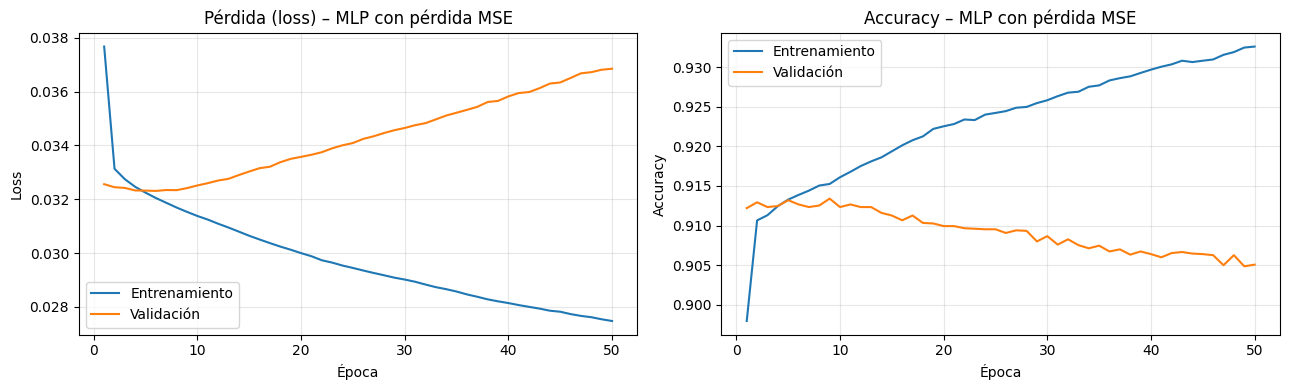

In [21]:
# Experimento 2: modelo con pérdida MSE (requiere y en formato one-hot)
from tensorflow.keras.utils import to_categorical

y_train_oh = to_categorical(y_train, num_classes=n_clases)
y_val_oh = to_categorical(y_val, num_classes=n_clases)
y_test_oh = to_categorical(y_test, num_classes=n_clases)

def crear_modelo_mse(n_features, n_clases):
    """MLP idéntico al base pero entrenado con pérdida MSE sobre etiquetas one-hot."""
    modelo = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(n_features,)),
        tf.keras.layers.Dense(64, activation='relu', name='capa_oculta_1'),
        tf.keras.layers.Dense(32, activation='relu', name='capa_oculta_2'),
        tf.keras.layers.Dense(n_clases, activation='softmax', name='capa_salida')
    ], name='MLP_mse')
    return modelo

modelo_mse = crear_modelo_mse(n_features, n_clases)

modelo_mse.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss='mean_squared_error',
    metrics=['accuracy']
)

historia_mse = modelo_mse.fit(
    X_train_scaled, y_train_oh,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_scaled, y_val_oh),
    verbose=1
)

graficar_curvas(historia_mse, titulo='MLP con pérdida MSE')

In [22]:
# Evaluación del modelo MSE en test
y_pred_prob_mse = modelo_mse.predict(X_test_scaled)
y_pred_mse = np.argmax(y_pred_prob_mse, axis=1)

accuracy_mse = accuracy_score(y_test, y_pred_mse)
precision_mse = precision_score(y_test, y_pred_mse, average='weighted')
recall_mse = recall_score(y_test, y_pred_mse, average='weighted')
f1_mse = f1_score(y_test, y_pred_mse, average='weighted')

comparacion_perdida = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision (weighted)', 'Recall (weighted)', 'F1-score (weighted)'],
    'Crossentropy (base)': [round(accuracy, 4), round(precision, 4), round(recall, 4), round(f1, 4)],
    'MSE': [round(accuracy_mse, 4), round(precision_mse, 4), round(recall_mse, 4), round(f1_mse, 4)]
})

print("=== Comparación de funciones de pérdida: Crossentropy vs MSE ===")
print(comparacion_perdida.to_string(index=False))

469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
=== Comparación de funciones de pérdida: Crossentropy vs MSE ===
             Métrica  Crossentropy (base)    MSE
            Accuracy               0.9033 0.9039
Precision (weighted)               0.9033 0.9040
   Recall (weighted)               0.9033 0.9039
 F1-score (weighted)               0.9033 0.9039


### Conclusión del Experimento 2: Crossentropy vs MSE

**Resultado:** En las métricas finales sobre el conjunto de prueba, ambas funciones de pérdida quedaron prácticamente empatadas, con MSE incluso levemente por encima de Crossentropy (Accuracy: 0,9039 vs 0,9033; F1-score: 0,9039 vs 0,9033). La diferencia es marginal y no representa una mejora relevante en la práctica.

Sin embargo, las **curvas de aprendizaje cuentan una historia distinta**: el modelo con MSE muestra un patrón de overfitting claro desde ~época 10, con el loss de validación subiendo mientras el de entrenamiento sigue bajando, y el accuracy de validación estancándose e incluso decayendo levemente (de ~0,915 a ~0,905), mientras el de entrenamiento sigue subiendo hasta 0,933. Esto sugiere que MSE está memorizando el set de entrenamiento sin traducir eso en mejor generalización.

**¿Por qué ocurre esto?** Aunque el resultado puntual en test sea similar, Crossentropy sigue siendo la opción **conceptualmente correcta** para clasificación: penaliza con más fuerza los errores donde el modelo está muy seguro y se equivoca, y su gradiente combinado con Softmax es más informativo durante el entrenamiento. MSE trata el problema como si fuera una regresión sobre probabilidades, lo que no captura tan bien la naturaleza de "elegir una clase entre varias". Por eso, aunque el resultado final en test sea parecido, se mantiene Sparse Categorical Crossentropy como la pérdida del modelo final, tanto por fundamento teórico como por el comportamiento más estable de sus curvas de validación.

## Experimento 3: Comparación de learning rate (0,001 vs 0,0005)

**¿Qué se hace?** Se entrena un cuarto modelo, con la misma arquitectura, activación (ReLU), pérdida y batch size del MLP base, pero con el optimizador Adam configurado con `learning_rate=0.0005` en lugar del valor por defecto (0,001, usado en el modelo base). Se mantienen fijos: arquitectura, pérdida, batch size y épocas.

**¿Por qué?** El learning rate controla el tamaño del paso que da el optimizador en cada actualización de pesos. Un valor muy alto puede hacer que el entrenamiento sea inestable o no converja bien; uno muy bajo hace que el modelo aprenda más lento y puede necesitar más épocas para alcanzar el mismo desempeño. Comparar dos valores permite verificar si el learning rate por defecto de Adam es una buena elección para este problema o si conviene ajustarlo.

Epoch 1/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.8958 - loss: 0.2990 - val_accuracy: 0.9105 - val_loss: 0.2411
Epoch 2/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9110 - loss: 0.2419 - val_accuracy: 0.9117 - val_loss: 0.2377
Epoch 3/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9118 - loss: 0.2380 - val_accuracy: 0.9120 - val_loss: 0.2364
Epoch 4/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9126 - loss: 0.2357 - val_accuracy: 0.9120 - val_loss: 0.2361
Epoch 5/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9128 - loss: 0.2340 - val_accuracy: 0.9123 - val_loss: 0.2359
Epoch 6/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9135 - loss: 0.2327 - val_accuracy: 0.9129 - val_loss: 0.2359
Epoch 7/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9138 - loss: 0.2316 - val_accuracy: 0.9128 - val_loss: 0.2359
Epoch 8/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9141 - loss: 0.2306 

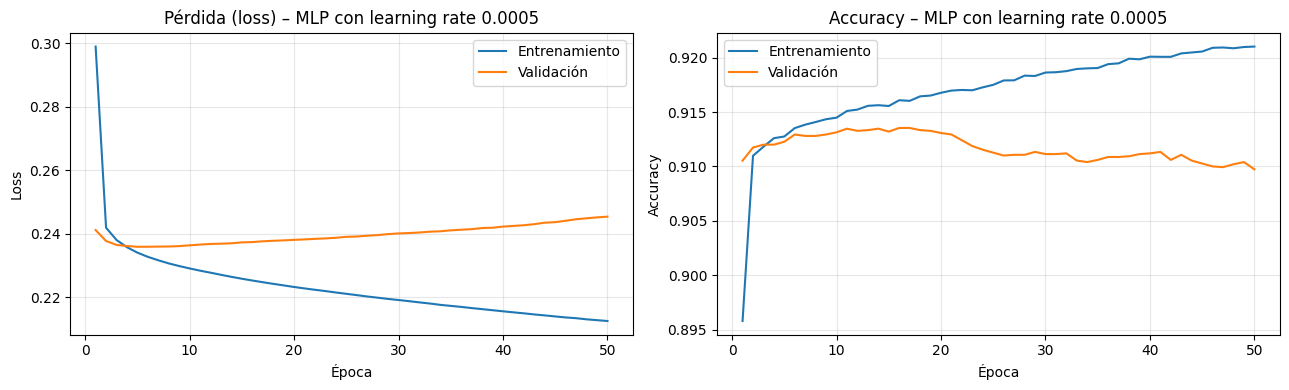

In [23]:
# Experimento 3: modelo con learning rate = 0.0005
def crear_modelo_lr(n_features, n_clases):
    """MLP idéntico al base, se diferencia solo en el learning rate del optimizador."""
    modelo = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(n_features,)),
        tf.keras.layers.Dense(64, activation='relu', name='capa_oculta_1'),
        tf.keras.layers.Dense(32, activation='relu', name='capa_oculta_2'),
        tf.keras.layers.Dense(n_clases, activation='softmax', name='capa_salida')
    ], name='MLP_lr0005')
    return modelo

modelo_lr = crear_modelo_lr(n_features, n_clases)

modelo_lr.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

historia_lr = modelo_lr.fit(
    X_train_scaled, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_scaled, y_val),
    verbose=1
)

graficar_curvas(historia_lr, titulo='MLP con learning rate 0.0005')

In [24]:
# Evaluación del modelo con LR 0.0005 en test
y_pred_prob_lr = modelo_lr.predict(X_test_scaled)
y_pred_lr = np.argmax(y_pred_prob_lr, axis=1)

accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr, average='weighted')
recall_lr = recall_score(y_test, y_pred_lr, average='weighted')
f1_lr = f1_score(y_test, y_pred_lr, average='weighted')

comparacion_lr = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision (weighted)', 'Recall (weighted)', 'F1-score (weighted)'],
    'LR 0.001 (base)': [round(accuracy, 4), round(precision, 4), round(recall, 4), round(f1, 4)],
    'LR 0.0005': [round(accuracy_lr, 4), round(precision_lr, 4), round(recall_lr, 4), round(f1_lr, 4)]
})

print("=== Comparación de learning rate: 0.001 vs 0.0005 ===")
print(comparacion_lr.to_string(index=False))

469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
=== Comparación de learning rate: 0.001 vs 0.0005 ===
             Métrica  LR 0.001 (base)  LR 0.0005
            Accuracy           0.9033     0.9059
Precision (weighted)           0.9033     0.9060
   Recall (weighted)           0.9033     0.9059
 F1-score (weighted)           0.9033     0.9060


### Conclusión del Experimento 3: Learning rate 0,001 vs 0,0005

**Resultado:** El modelo con learning rate 0,0005 superó al modelo base (LR 0,001) en las 4 métricas sobre el conjunto de prueba (Accuracy: 0,9059 vs 0,9033; F1-score: 0,9060 vs 0,9033). Además, sus curvas de aprendizaje mostraron una brecha más contenida entre train y validación que las del modelo base, sin el patrón de sobreajuste marcado visto en los experimentos anteriores.

**¿Por qué ocurre esto?** Un learning rate más bajo hace que el optimizador dé pasos más pequeños en cada actualización de pesos, lo que puede evitar que el modelo "sobrepase" mínimos buenos de la función de pérdida y ayuda a una convergencia más estable, aunque más lenta. En este caso, con 50 épocas disponibles, ese ritmo más conservador le permitió al modelo generalizar levemente mejor que con el learning rate por defecto de Adam. Este resultado sugiere que 0,0005 es un buen candidato a incluir en el modelo final ajustado (Sección 10 de la consigna).

## Experimento 4: Regularización con Dropout (sin Dropout vs con Dropout)

**¿Qué se hace?** Se entrena un quinto modelo, con la misma arquitectura, activación (ReLU) y demás hiperparámetros del MLP base, pero agregando una capa `Dropout` después de cada capa oculta (tasa de 0,3). Se mantienen fijos: arquitectura base, pérdida, optimizador, batch size, learning rate y épocas.

**¿Por qué?** Dropout es una técnica de regularización que, en cada paso de entrenamiento, "apaga" aleatoriamente un porcentaje de neuronas de la capa. Esto evita que la red dependa demasiado de neuronas específicas y la obliga a aprender representaciones más robustas, lo que suele reducir el overfitting. Es especialmente relevante acá porque en los experimentos anteriores (Tanh, MSE) se observó una brecha creciente entre train y validación a medida que avanzaban las épocas.

Epoch 1/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.8749 - loss: 0.3588 - val_accuracy: 0.9140 - val_loss: 0.2366
Epoch 2/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - accuracy: 0.9028 - loss: 0.2786 - val_accuracy: 0.9133 - val_loss: 0.2345
Epoch 3/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9038 - loss: 0.2724 - val_accuracy: 0.9136 - val_loss: 0.2348
Epoch 4/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9059 - loss: 0.2667 - val_accuracy: 0.9141 - val_loss: 0.2350
Epoch 5/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9067 - loss: 0.2668 - val_accuracy: 0.9147 - val_loss: 0.2355
Epoch 6/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9063 - loss: 0.2636 - val_accuracy: 0.9128 - val_loss: 0.2358
Epoch 7/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9079 - loss: 0.2626 - val_accuracy: 0.9135 - val_loss: 0.2350
Epoch 8/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9070 - loss: 0.2625 

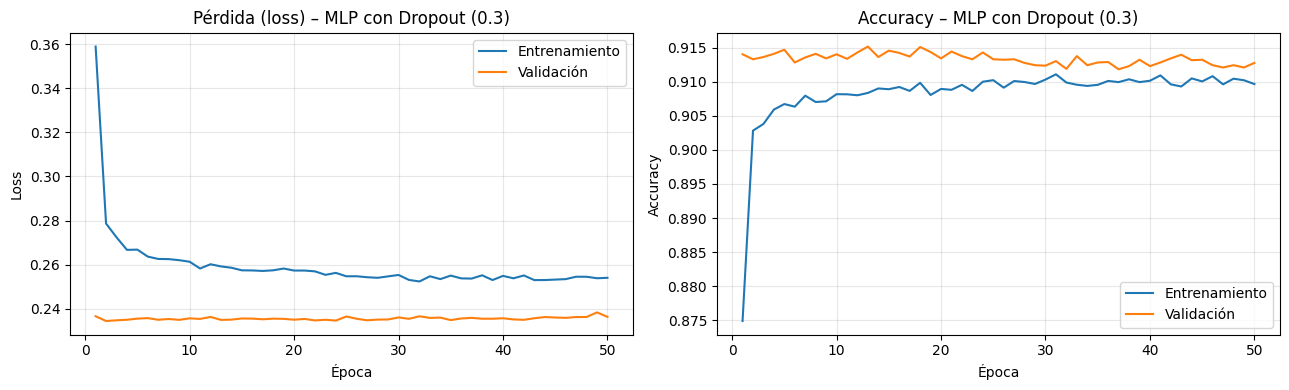

In [25]:
# Experimento 4: modelo con Dropout (tasa 0.3) después de cada capa oculta
def crear_modelo_dropout(n_features, n_clases, tasa_dropout=0.3):
    """MLP idéntico al base, con Dropout después de cada capa oculta."""
    modelo = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(n_features,)),
        tf.keras.layers.Dense(64, activation='relu', name='capa_oculta_1'),
        tf.keras.layers.Dropout(tasa_dropout, name='dropout_1'),
        tf.keras.layers.Dense(32, activation='relu', name='capa_oculta_2'),
        tf.keras.layers.Dropout(tasa_dropout, name='dropout_2'),
        tf.keras.layers.Dense(n_clases, activation='softmax', name='capa_salida')
    ], name='MLP_dropout')
    return modelo

modelo_dropout = crear_modelo_dropout(n_features, n_clases)

modelo_dropout.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

historia_dropout = modelo_dropout.fit(
    X_train_scaled, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_scaled, y_val),
    verbose=1
)

graficar_curvas(historia_dropout, titulo='MLP con Dropout (0.3)')

In [26]:
# Evaluación del modelo con Dropout en test
y_pred_prob_dropout = modelo_dropout.predict(X_test_scaled)
y_pred_dropout = np.argmax(y_pred_prob_dropout, axis=1)

accuracy_dropout = accuracy_score(y_test, y_pred_dropout)
precision_dropout = precision_score(y_test, y_pred_dropout, average='weighted')
recall_dropout = recall_score(y_test, y_pred_dropout, average='weighted')
f1_dropout = f1_score(y_test, y_pred_dropout, average='weighted')

comparacion_dropout = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision (weighted)', 'Recall (weighted)', 'F1-score (weighted)'],
    'Sin Dropout (base)': [round(accuracy, 4), round(precision, 4), round(recall, 4), round(f1, 4)],
    'Con Dropout (0.3)': [round(accuracy_dropout, 4), round(precision_dropout, 4), round(recall_dropout, 4), round(f1_dropout, 4)]
})

print("=== Comparación de regularización: sin Dropout vs con Dropout ===")
print(comparacion_dropout.to_string(index=False))

469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
=== Comparación de regularización: sin Dropout vs con Dropout ===
             Métrica  Sin Dropout (base)  Con Dropout (0.3)
            Accuracy              0.9033             0.9111
Precision (weighted)              0.9033             0.9112
   Recall (weighted)              0.9033             0.9111
 F1-score (weighted)              0.9033             0.9111


### Conclusión del Experimento 4: Sin Dropout vs con Dropout

**Resultado:** El modelo con Dropout (0,3) superó claramente al modelo base en las 4 métricas sobre el conjunto de prueba (Accuracy: 0,9111 vs 0,9033; F1-score: 0,9111 vs 0,9033). Es la mejora más consistente observada hasta ahora entre todos los experimentos. Además, las curvas de aprendizaje mostraron el mejor comportamiento de generalización: el loss de validación se mantuvo estable y por debajo del de entrenamiento durante las 50 épocas, sin ninguna señal de overfitting, y el accuracy de validación se mantuvo por encima del de entrenamiento de forma consistente.

**¿Por qué ocurre esto?** Al apagar aleatoriamente un 30% de las neuronas en cada paso de entrenamiento, Dropout evita que la red dependa excesivamente de combinaciones específicas de neuronas, forzándola a aprender representaciones más robustas y redundantes. Esto reduce el overfitting observado en el modelo base (que ya mostraba cierta brecha entre train y validación) y se traduce en mejor desempeño sobre datos no vistos. Dropout es, hasta este punto,

## Experimento 5: Modelo final ajustado (base vs modelo ajustado)

**¿Qué se hace?** A partir de los resultados de los experimentos anteriores, se construye un modelo final que combina las dos mejoras que mostraron mejor desempeño de forma individual: **Dropout (0,3)** después de cada capa oculta (Experimento 4) y **learning rate 0,0005** en el optimizador Adam (Experimento 3). Se mantiene la misma arquitectura, activación ReLU, pérdida y batch size del modelo base.

**¿Por qué esta configuración?** Dropout fue la mejora individual más consistente (Accuracy 0,9111 vs 0,9033 del base) porque redujo el overfitting observado en las curvas de aprendizaje. El learning rate 0,0005 también mejoró el resultado (0,9059) y produjo curvas más estables. Ambas mejoras atacan problemas distintos y complementarios: Dropout regulariza la capacidad del modelo, mientras que un learning rate más bajo estabiliza la optimización. Por eso se prueba si, combinadas, producen una mejora mayor que cada una por separado.

Epoch 1/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8539 - loss: 0.4045 - val_accuracy: 0.9119 - val_loss: 0.2412
Epoch 2/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9005 - loss: 0.2932 - val_accuracy: 0.9141 - val_loss: 0.2358
Epoch 3/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9033 - loss: 0.2779 - val_accuracy: 0.9132 - val_loss: 0.2352
Epoch 4/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9050 - loss: 0.2704 - val_accuracy: 0.9125 - val_loss: 0.2350
Epoch 5/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9061 - loss: 0.2680 - val_accuracy: 0.9132 - val_loss: 0.2340
Epoch 6/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9070 - loss: 0.2649 - val_accuracy: 0.9137 - val_loss: 0.2335
Epoch 7/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9075 - loss: 0.2642 - val_accuracy: 0.9135 - val_loss: 0.2347
Epoch 8/50
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9075 - loss: 0.2626 - 

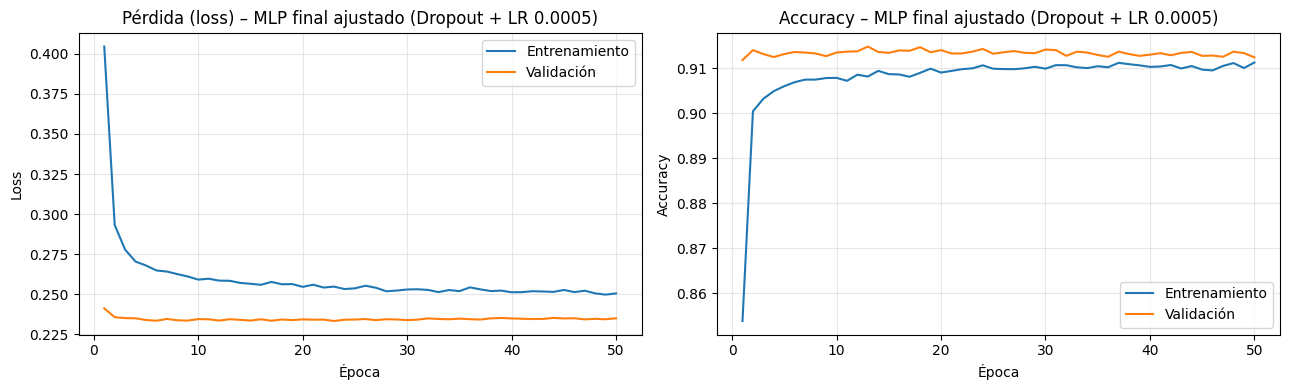

In [27]:
# Experimento 5: modelo final ajustado (Dropout 0.3 + learning rate 0.0005)
def crear_modelo_final(n_features, n_clases, tasa_dropout=0.3):
    """MLP final: arquitectura base + Dropout + learning rate ajustado."""
    modelo = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(n_features,)),
        tf.keras.layers.Dense(64, activation='relu', name='capa_oculta_1'),
        tf.keras.layers.Dropout(tasa_dropout, name='dropout_1'),
        tf.keras.layers.Dense(32, activation='relu', name='capa_oculta_2'),
        tf.keras.layers.Dropout(tasa_dropout, name='dropout_2'),
        tf.keras.layers.Dense(n_clases, activation='softmax', name='capa_salida')
    ], name='MLP_final')
    return modelo

modelo_final = crear_modelo_final(n_features, n_clases)

modelo_final.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

historia_final = modelo_final.fit(
    X_train_scaled, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_scaled, y_val),
    verbose=1
)

graficar_curvas(historia_final, titulo='MLP final ajustado (Dropout + LR 0.0005)')

In [28]:
# Evaluación del modelo final ajustado en test
y_pred_prob_final = modelo_final.predict(X_test_scaled)
y_pred_final = np.argmax(y_pred_prob_final, axis=1)

accuracy_final = accuracy_score(y_test, y_pred_final)
precision_final = precision_score(y_test, y_pred_final, average='weighted')
recall_final = recall_score(y_test, y_pred_final, average='weighted')
f1_final = f1_score(y_test, y_pred_final, average='weighted')

# Tabla comparativa: base vs modelo final ajustado
comparacion_final = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision (weighted)', 'Recall (weighted)', 'F1-score (weighted)'],
    'MLP base': [round(accuracy, 4), round(precision, 4), round(recall, 4), round(f1, 4)],
    'MLP final ajustado': [round(accuracy_final, 4), round(precision_final, 4), round(recall_final, 4), round(f1_final, 4)]
})

print("=== Comparación: MLP base vs MLP final ajustado ===")
print(comparacion_final.to_string(index=False))

# Cuadro resumen de TODOS los experimentos, para la sección de conclusiones
resumen_todos = pd.DataFrame({
    'Modelo': ['Base (ReLU, CE, LR 0.001, sin Dropout)', 'Tanh', 'MSE', 'LR 0.0005',
               'Dropout 0.3', 'Final (Dropout + LR 0.0005)'],
    'Accuracy': [accuracy, accuracy_tanh, accuracy_mse, accuracy_lr, accuracy_dropout, accuracy_final],
    'Precision': [precision, precision_tanh, precision_mse, precision_lr, precision_dropout, precision_final],
    'Recall': [recall, recall_tanh, recall_mse, recall_lr, recall_dropout, recall_final],
    'F1-score': [f1, f1_tanh, f1_mse, f1_lr, f1_dropout, f1_final]
}).round(4)

print("\n=== CUADRO RESUMEN – Todos los experimentos ===")
print(resumen_todos.to_string(index=False))

469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step
=== Comparación: MLP base vs MLP final ajustado ===
             Métrica  MLP base  MLP final ajustado
            Accuracy    0.9033              0.9116
Precision (weighted)    0.9033              0.9116
   Recall (weighted)    0.9033              0.9116
 F1-score (weighted)    0.9033              0.9116

=== CUADRO RESUMEN – Todos los experimentos ===
                                Modelo  Accuracy  Precision  Recall  F1-score
Base (ReLU, CE, LR 0.001, sin Dropout)    0.9033     0.9033  0.9033    0.9033
                                  Tanh    0.9021     0.9021  0.9021    0.9021
                                   MSE    0.9039     0.9040  0.9039    0.9039
                             LR 0.0005    0.9059     0.9060  0.9059    0.9060
                           Dropout 0.3    0.9111     0.9112  0.9111    0.9111
           Final (Dropout + LR 0.0005)    0.9116     0.9116  0.9116    0.9116


### Conclusión del Experimento 5: Modelo final ajustado

**Resultado:** El modelo final (Dropout 0,3 + learning rate 0,0005) obtuvo el mejor desempeño de todo el notebook: Accuracy 0,9116, superando al modelo base (0,9033) y también a cada mejora aplicada por separado (Dropout solo: 0,9111; LR 0,0005 solo: 0,9059). Las curvas de aprendizaje confirman esto: el loss de validación se mantiene estable y por debajo del de entrenamiento durante las 50 épocas, y el accuracy de validación se mantiene consistentemente por encima del de entrenamiento, sin ninguna brecha creciente.

**¿Por qué se eligió esta configuración?** Dropout y el learning rate reducido atacan problemas complementarios: Dropout regulariza la capacidad del modelo evitando que memorice el train set, mientras que un learning rate más bajo estabiliza el proceso de optimización. Combinados, producen una mejora mayor que cada uno por separado (0,9116 vs 0,9111 y 0,9059 individualmente), lo que confirma que ambos ajustes son compatibles y se refuerzan mutuamente. Por eso se selecciona esta configuración como el **modelo final** del proyecto.

## Conclusiones finales

**Configuración con mejores resultados:** El modelo final, que combina Dropout (0,3) y learning rate 0,0005, obtuvo el mejor desempeño de todos los experimentos (Accuracy 0,9116), superando al modelo base (0,9033) en 0,83 puntos porcentuales.

**Efecto de cada componente evaluado:**
- **Activación (ReLU vs Tanh):** ReLU fue superior (0,9033 vs 0,9021) y generalizó mejor, sin el overfitting que mostró Tanh desde la época 10.
- **Pérdida (Crossentropy vs MSE):** las métricas finales fueron casi idénticas, pero Crossentropy es la opción conceptualmente correcta para clasificación y mostró curvas más estables.
- **Learning rate (0,001 vs 0,0005):** el valor más bajo mejoró el resultado (0,9059) y estabilizó el entrenamiento.
- **Regularización (Dropout):** fue la mejora individual más importante (0,9111), reduciendo claramente el overfitting observado en el modelo base.

**Limitaciones y mejoras posibles:** No se exploró una búsqueda más amplia de hiperparámetros (grid o random search) ni combinaciones adicionales de tasas de Dropout o learning rate, dado que la consigna acota explícitamente la dificultad del encargo. Como trabajo futuro, podría evaluarse una tasa de Dropout distinta (por ejemplo 0,2 o 0,4), técnicas adicionales como Early Stopping o Batch Normalization, o el efecto de la métrica macro (en vez de weighted) para evaluar el desempeño en la clase minoritaria de forma más exigente.